In [1]:
import os, json, shutil
from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from tqdm import tqdm
from glob import glob
import pandas as pd
from medpy.metric.binary import hd95 as medpy_hd95
import torch
import nnunetv2 as _nnunetv2_pkg

SPLIT_ROOT = Path(r"D:\brats_goat_experiments\data\split")
TRAIN_DIR = SPLIT_ROOT / "train"
VAL_DIR = SPLIT_ROOT / "val"
TEST_DIR = SPLIT_ROOT / "test"

NNUNET_BASE = Path(r"D:\brats_goat_experiments\models_configs\nnUNet_ResEnc_GOAT_patchsampling")
NNUNET_RAW = NNUNET_BASE / "nnUNet_raw"
NNUNET_PREP = NNUNET_BASE / "nnUNet_preprocessed"
NNUNET_RES = NNUNET_BASE / "nnUNet_results"

for p in [NNUNET_RAW, NNUNET_PREP, NNUNET_RES]:
    p.mkdir(parents=True, exist_ok=True)

os.environ["nnUNet_raw"] = str(NNUNET_RAW)
os.environ["nnUNet_preprocessed"] = str(NNUNET_PREP)
os.environ["nnUNet_results"] = str(NNUNET_RES)

DATASET_ID = 908
DATASET_NAME = "BraTS-GoAT_ResEnc_patch"
DATASET_FOLDER = NNUNET_RAW / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}"
imagesTr = DATASET_FOLDER / "imagesTr"
labelsTr = DATASET_FOLDER / "labelsTr"
imagesTs = DATASET_FOLDER / "imagesTs"

for p in [imagesTr, labelsTr, imagesTs]:
    p.mkdir(parents=True, exist_ok=True)

# Configuração ResEnc nnUNetv2
PLANNER    = "nnUNetPlannerResEncM"    # Planner M
PLANS_NAME = "nnUNetResEncUNetMPlans"
# Trainer customizado: prioriza patches centrados na classe 1 (NCR/NC).
TRAINER    = "nnUNetTrainer_100epochs_NCR" # 100 epocas + NCR-centered patch sampling
CONFIG     = "3d_fullres"
FOLD       = 0

# Proporção de patches forçados-FG centrados em voxels da classe 1 (NCR/NC).
NCR_CENTERED_PATCH_PROB = 0.50

DATASET_FOLDER

WindowsPath('D:/brats_goat_experiments/models_configs/nnUNet_ResEnc_GOAT_patchsampling/nnUNet_raw/Dataset908_BraTS-GoAT_ResEnc_patch')

In [2]:
# Lê IDs de pacientes a partir das pastas
def get_patient_ids(directory: Path) -> list:
    if not directory.exists():
        return []
    return sorted([d.name for d in directory.iterdir() if d.is_dir()])

train_ids = get_patient_ids(TRAIN_DIR)
val_ids = get_patient_ids(VAL_DIR)
test_subfolders = {d.name: d for d in TEST_DIR.iterdir() if d.is_dir()}

print(f"Train: {len(train_ids)} pacientes")
print(f"Val: {len(val_ids)} pacientes")
print(f"Test subfolders: {list(test_subfolders.keys())}")
print("OK: estrutura de pastas verificada")

Train: 945 pacientes
Val: 202 pacientes
Test subfolders: ['PED', 'SSA', 'test_GLI-MET-MEN']
OK: estrutura de pastas verificada


In [3]:
MODS = ["t1n", "t1c", "t2w", "t2f"]
FILE_ENDING = ".nii.gz"

def case_dir(split_name: str, case_id: str) -> Path:
    if split_name == "train":
        return TRAIN_DIR / case_id
    elif split_name == "val":
        return VAL_DIR / case_id
    elif split_name.startswith("test"):
        test_subfolder = split_name.split("/")[1] if "/" in split_name else split_name
        return TEST_DIR / test_subfolder / case_id
    return None

def find_file(folder: Path, key: str) -> Path:
    for cand in [folder / f"{key}.nii.gz", folder / f"{key}.nii"]:
        if cand.exists():
            return cand
    cands = sorted(list(folder.glob(f"*{key}*.nii*")))
    if key == "t1n":
        cands = [c for c in cands if "t1c" not in c.name.lower()]
    if not cands:
        raise FileNotFoundError(f"{key} not found in {folder}")
    return cands[0]

def save_as_niigz(src_path: Path, dst_path: Path):
    if src_path.name.lower().endswith(".nii.gz"):
        shutil.copy2(src_path, dst_path)
        return
    img = nib.load(str(src_path))
    nib.save(img, str(dst_path))

def save_label_remap_niigz(seg_path: Path, dst_path: Path):
    img = nib.load(str(seg_path))
    data = np.asanyarray(img.dataobj).astype(np.int16)
    out = nib.Nifti1Image(data, img.affine, img.header)
    nib.save(out, str(dst_path))

def check_case(split_name: str, case_id: str):
    d = case_dir(split_name, case_id)
    assert d.exists(), f"Missing folder: {d}"
    _ = [find_file(d, m) for m in MODS]
    _ = find_file(d, "seg")
    return True

for cid in train_ids[:3]:
    check_case("train", cid)
print("OK")

OK


In [4]:
def export_case_to_nnunet(split_name: str, case_id: str, to_images: Path, to_labels: Path | None):
    d = case_dir(split_name, case_id)
    for ch, mod in enumerate(MODS):
        src = find_file(d, mod)
        dst = to_images / f"{case_id}_{ch:04d}{FILE_ENDING}"
        save_as_niigz(src, dst)
    if to_labels is not None:
        seg = find_file(d, "seg")
        dst = to_labels / f"{case_id}{FILE_ENDING}"
        save_label_remap_niigz(seg, dst)

for cid in tqdm(train_ids, desc="Export train -> imagesTr/labelsTr"):
    export_case_to_nnunet("train", cid, imagesTr, labelsTr)

for cid in tqdm(val_ids, desc="Export val -> imagesTr/labelsTr"):
    export_case_to_nnunet("val", cid, imagesTr, labelsTr)

case_to_subfolder = {}
test_ids_by_subfolder = {}

for subfolder_name, subfolder_path in test_subfolders.items():
    ids = get_patient_ids(subfolder_path)
    test_ids_by_subfolder[subfolder_name] = ids
    for cid in tqdm(ids, desc=f"Export {subfolder_name} -> imagesTs"):
        export_case_to_nnunet(f"test/{subfolder_name}", cid, imagesTs, None)
        case_to_subfolder[cid] = subfolder_name

print(f"Total train:  {len(list(imagesTr.glob(f'*{FILE_ENDING}')))}")
print(f"Total labels: {len(list(labelsTr.glob(f'*{FILE_ENDING}')))}")
print(f"Total test:   {len(list(imagesTs.glob(f'*{FILE_ENDING}')))}")
print("Distribuição teste:")
for sub, ids in test_ids_by_subfolder.items():
    print(f"  {sub}: {len(ids)} pacientes")

Export test_GLI-MET-MEN -> imagesTs: 100%|██████████| 204/204 [00:05<00:00, 34.63it/s]


Total train:  4588
Total labels: 1147
Total test:   1796
Distribuição teste:
  PED: 99 pacientes
  SSA: 146 pacientes
  test_GLI-MET-MEN: 204 pacientes


In [5]:
dataset_json = {
    "channel_names": {"0": "T1n", "1": "T1c", "2": "T2w", "3": "T2f"},
    "labels": {"background": 0, "NCR/NET": 1, "ED": 2, "ET": 3},
    "numTraining": len(list(labelsTr.glob(f"*{FILE_ENDING}"))),
    "file_ending": FILE_ENDING
}

with open(DATASET_FOLDER / "dataset.json", "w", encoding="utf-8") as f:
    json.dump(dataset_json, f, indent=2, ensure_ascii=False)

DATASET_FOLDER / "dataset.json"

WindowsPath('D:/brats_goat_experiments/models_configs/nnUNet_ResEnc_GOAT_patchsampling/nnUNet_raw/Dataset908_BraTS-GoAT_ResEnc_patch/dataset.json')

In [6]:
!nnUNetv2_plan_and_preprocess -d {DATASET_ID} --verify_dataset_integrity -pl {PLANNER} -c {CONFIG} -np 4

Fingerprint extraction...
Dataset908_BraTS-GoAT_ResEnc_patch
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer
Experiment planning...
Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [140. 171. 136.], 3d_lowres: [140, 171, 136]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 107, 'patch_size': (np.int64(192), np.int64(160)), 'median_image_size_in_voxels': array([171., 136.]), 'spacing': array([1., 1.]), 'normalization_schemes': ['ZScoreNormalization', 'ZScoreNormalization', 'ZScoreNormalization', 'ZScoreNormalization'], 'use_mask_for_norm': [True, True, True, True], 'resampling_fn_data': 'resample_


100%|##########| 1147/1147 [02:05<00:00,  9.15it/s]

100%|##########| 1147/1147 [23:04<00:00,  1.21s/it]


In [7]:
preprocessed_dataset = NNUNET_PREP / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}"
preprocessed_dataset.exists()

True

In [8]:
preprocessed_dataset = NNUNET_PREP / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}"
splits_final = [{"train": sorted(train_ids), "val": sorted(val_ids)}]
with open(preprocessed_dataset / "splits_final.json", "w", encoding="utf-8") as f:
    json.dump(splits_final, f, indent=2, ensure_ascii=False)

preprocessed_dataset / "splits_final.json"

WindowsPath('D:/brats_goat_experiments/models_configs/nnUNet_ResEnc_GOAT_patchsampling/nnUNet_preprocessed/Dataset908_BraTS-GoAT_ResEnc_patch/splits_final.json')

In [9]:
prep = Path(os.environ["nnUNet_preprocessed"]) / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}"
print("Preprocessed dir:", prep)

plans_files = list(prep.glob(f"{PLANS_NAME}*.json"))
print("Plans files:", plans_files)

if plans_files:
    with open(plans_files[0], "r", encoding="utf-8") as f:
        plans_json = json.load(f)
    print("Top keys:", plans_json.keys())

Preprocessed dir: D:\brats_goat_experiments\models_configs\nnUNet_ResEnc_GOAT_patchsampling\nnUNet_preprocessed\Dataset908_BraTS-GoAT_ResEnc_patch
Plans files: [WindowsPath('D:/brats_goat_experiments/models_configs/nnUNet_ResEnc_GOAT_patchsampling/nnUNet_preprocessed/Dataset908_BraTS-GoAT_ResEnc_patch/nnUNetResEncUNetMPlans.json')]
Top keys: dict_keys(['dataset_name', 'plans_name', 'original_median_spacing_after_transp', 'original_median_shape_after_transp', 'image_reader_writer', 'transpose_forward', 'transpose_backward', 'configurations', 'experiment_planner_used', 'label_manager', 'foreground_intensity_properties_per_channel'])


In [10]:
# ── Registro do trainer customizado: nnUNetTrainer_100epochs_NCR ─────────────
#
# Onde a priorização da classe 1 (NCR/NC) é aplicada:
#   - Dentro de nnUNetDataLoader.get_bbox(), via subclasse nnUNetDataLoader_NCR.
#   - O trainer (nnUNetTrainer_100epochs_NCR) adapta get_dataloaders sem
#     reescrevê-lo: redireciona apenas a PRIMEIRA construção do DataLoader
#     (loader de treino) para a subclasse NCR. A validação mantém o original.
#
# Proporção de patches centrados na classe 1:
#   - Controlada por NCR_CENTERED_PATCH_PROB (definido no setup). 50% dos
#     patches forçados-FG terão centro em voxel da classe 1; os 50% restantes
#     seguem o sorteio uniforme original do nnUNet entre as classes FG presentes.
#
# Fallback automático quando a classe 1 não existe no caso:
#   - Se class_locations[1] está vazio/ausente, overwrite_class permanece None
#     e a chamada cai exatamente na estratégia original (escolha aleatória
#     entre as classes FG presentes — ED, ET).
#
# O patch continua respeitando os limites do volume (super().get_bbox cuida do
# clip/pad nas bordas) e imagem/máscara permanecem alinhadas (apenas o centro
# do patch é alterado — nenhuma transformação adicional é introduzida).

_NCR_TRAINER_SRC = f'''import numpy as np
import nnunetv2.training.nnUNetTrainer.nnUNetTrainer as _trainer_module
from nnunetv2.training.dataloading.data_loader import nnUNetDataLoader
from nnunetv2.training.nnUNetTrainer.variants.training_length.nnUNetTrainer_Xepochs import nnUNetTrainer_100epochs

# Proporção de patches forçados-FG centrados em voxels da classe 1 (NCR/NC).
NCR_CENTERED_PATCH_PROB = {NCR_CENTERED_PATCH_PROB}


class nnUNetDataLoader_NCR(nnUNetDataLoader):

    def get_bbox(self, data_shape, force_fg, class_locations,
                 overwrite_class=None, verbose=False):
        # === priorização da classe 1 (NCR/NC) ===
        if force_fg and overwrite_class is None and class_locations is not None:
            ncr_locs = class_locations.get(1, None)
            if ncr_locs is not None and len(ncr_locs) > 0:
                if np.random.rand() < NCR_CENTERED_PATCH_PROB:
                    overwrite_class = 1
        # ========================================
        return super().get_bbox(data_shape, force_fg, class_locations,
                                overwrite_class=overwrite_class, verbose=verbose)


class nnUNetTrainer_100epochs_NCR(nnUNetTrainer_100epochs):

    def get_dataloaders(self):
        # Adapta get_dataloaders sem reescrevê-lo: redireciona apenas a primeira
        # construção de nnUNetDataLoader (treino) para nnUNetDataLoader_NCR.
        # A segunda construção (validação) recebe a classe original.
        _orig_cls = _trainer_module.nnUNetDataLoader
        _state = {{"n": 0}}

        def _factory(*args, **kwargs):
            _state["n"] += 1
            cls = nnUNetDataLoader_NCR if _state["n"] == 1 else _orig_cls
            return cls(*args, **kwargs)

        _trainer_module.nnUNetDataLoader = _factory
        try:
            return super().get_dataloaders()
        finally:
            _trainer_module.nnUNetDataLoader = _orig_cls
'''

_nnunet_pkg_dir = Path(_nnunetv2_pkg.__file__).parent
_trainer_variants_dir = _nnunet_pkg_dir / "training" / "nnUNetTrainer" / "variants"
_trainer_file = _trainer_variants_dir / "nnUNetTrainer_100epochs_NCR.py"
_trainer_file.write_text(_NCR_TRAINER_SRC, encoding="utf-8")

# Validação: importa o trainer recém-escrito para garantir que o CLI o encontre.
import importlib
_mod_name = "nnunetv2.training.nnUNetTrainer.variants.nnUNetTrainer_100epochs_NCR"
if _mod_name in importlib.sys.modules:
    importlib.reload(importlib.sys.modules[_mod_name])
_mod = importlib.import_module(_mod_name)
assert hasattr(_mod, "nnUNetTrainer_100epochs_NCR"), "Trainer customizado não foi registrado corretamente."

print(f"Trainer salvo em: {_trainer_file}")
print(f"NCR_CENTERED_PATCH_PROB = {NCR_CENTERED_PATCH_PROB}")
print(f"Trainer registrado: {TRAINER}")

Trainer salvo em: C:\Users\dados\anaconda3\envs\Testes_mestrado\lib\site-packages\nnunetv2\training\nnUNetTrainer\variants\nnUNetTrainer_100epochs_NCR.py
NCR_CENTERED_PATCH_PROB = 0.5
Trainer registrado: nnUNetTrainer_100epochs_NCR


In [11]:
!nnUNetv2_train {DATASET_ID} {CONFIG} {FOLD} -device cuda -p {PLANS_NAME} -tr {TRAINER}

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-05-17 23:38:04.434734: do_dummy_2d_data_aug: False
2026-05-17 23:38:04.436738: Using splits from existing split file: D:\brats_goat_experiments\models_configs\nnUNet_ResEnc_GOAT_patchsampling\nnUNet_preprocessed\Dataset908_BraTS-GoAT_ResEnc_patch\splits_final.json
2026-05-17 23:38:04.438740: The split file contains 1 splits.
2026-05-17 23:38:04.438740: Desired fold for training: 0
2026-05-17 23:38:04.438740: This split has 945 training and 202 validation cases.
using pin_memory on device 0
using pin_memory on device 0

This is the configuration used by this trainin

In [12]:
pattern = str(NNUNET_RES / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}" / "*" / f"fold_{FOLD}" / "validation" / "summary.json")
cands = glob(pattern)
cands[:2], len(cands)

(['D:\\brats_goat_experiments\\models_configs\\nnUNet_ResEnc_GOAT_patchsampling\\nnUNet_results\\Dataset908_BraTS-GoAT_ResEnc_patch\\nnUNetTrainer_100epochs_NCR__nnUNetResEncUNetMPlans__3d_fullres\\fold_0\\validation\\summary.json'],
 1)

In [13]:
if cands:
    with open(cands[0], "r", encoding="utf-8") as f:
        summary = json.load(f)
    list(summary.keys())

In [14]:
PRED_TEST_OUT = Path(r"D:\nnUNet_preds\brats_goat_resenc_ncrPatch_test_pred")
PRED_TEST_OUT.mkdir(parents=True, exist_ok=True)

!nnUNetv2_predict -i "{imagesTs}" -o "{PRED_TEST_OUT}" -d {DATASET_ID} -c {CONFIG} -f {FOLD} -p {PLANS_NAME} -tr {TRAINER}


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 449 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 449 cases that I would like to predict

Predicting BraTS-GoAT-00003:
perform_everything_on_device: True
sending off prediction to background worker for resampling and export
done with BraTS-GoAT-00003

Predicting BraTS-GoAT-00014:
perform_everything_on_device: True
sending off prediction to background worker for resampling and export
done with BraTS-GoAT-00014

Predicting BraTS-GoAT-00025:
perform_everything_on_device: True
sending off prediction to background worke


100%|##########| 8/8 [00:04<00:00,  1.71it/s]

100%|##########| 8/8 [00:03<00:00,  2.27it/s]

100%|##########| 8/8 [00:03<00:00,  2.26it/s]

100%|##########| 8/8 [00:03<00:00,  2.26it/s]

100%|##########| 8/8 [00:03<00:00,  2.26it/s]

100%|##########| 8/8 [00:03<00:00,  2.26it/s]

100%|##########| 8/8 [00:03<00:00,  2.25it/s]

100%|##########| 8/8 [00:03<00:00,  2.26it/s]

100%|##########| 8/8 [00:03<00:00,  2.27it/s]

100%|##########| 8/8 [00:03<00:00,  2.26it/s]

100%|##########| 8/8 [00:03<00:00,  2.26it/s]

100%|##########| 8/8 [00:03<00:00,  2.25it/s]

100%|##########| 8/8 [00:03<00:00,  2.25it/s]

100%|##########| 8/8 [00:03<00:00,  2.26it/s]

100%|##########| 8/8 [00:03<00:00,  2.26it/s]

100%|##########| 8/8 [00:03<00:00,  2.26it/s]

100%|##########| 8/8 [00:03<00:00,  2.25it/s]

100%|##########| 8/8 [00:03<00:00,  2.26it/s]

100%|##########| 4/4 [00:01<00:00,  2.28it/s]

100%|##########| 8/8 [00:03<00:00,  2.27it/s]

100%|##########| 8/8 [00:03<00:00,  2.26it/s]

100%|#######

In [15]:
def load_arr(p):
    arr = np.asanyarray(nib.load(str(p)).dataobj)
    return np.squeeze(arr)

def dice(a, b):
    inter = np.count_nonzero(a & b)
    denom = np.count_nonzero(a) + np.count_nonzero(b)
    return 1.0 if denom == 0 else (2.0 * inter / denom)

def get_pred_path(cid: str) -> Path:
    p = PRED_TEST_OUT / f"{cid}.nii.gz"
    if p.exists():
        return p
    p = PRED_TEST_OUT / f"{cid}.nii"
    if p.exists():
        return p
    raise FileNotFoundError(f"Pred não encontrada para {cid}")

all_test_ids = [cid for ids in test_ids_by_subfolder.values() for cid in ids]

rows = []
for cid in tqdm(all_test_ids, desc="Dice por caso"):
    sub = case_to_subfolder[cid]
    gt_path = find_file(case_dir(f"test/{sub}", cid), "seg")
    pr_path = get_pred_path(cid)

    gt = load_arr(gt_path).astype(np.int16)
    pr = load_arr(pr_path).astype(np.int16)

    d1 = dice(gt == 1, pr == 1)
    d2 = dice(gt == 2, pr == 2)
    d3 = dice(gt == 3, pr == 3)
    wt = dice(((gt==1)|(gt==2)|(gt==3)), ((pr==1)|(pr==2)|(pr==3)))
    tc = dice(((gt == 1) | (gt == 3)), ((pr == 1) | (pr == 3)))

    rows.append({
        "id":       cid,
        "subfolder": sub,
        "dice_c1":  d1,
        "dice_c2":  d2,
        "dice_ET":  d3,
        "dice_WT":  wt,
        "dice_TC":  tc,
    })

df = pd.DataFrame(rows)
df[["dice_c1", "dice_c2", "dice_ET", "dice_WT", "dice_TC"]].describe()

Dice por caso: 100%|██████████| 449/449 [01:13<00:00,  6.14it/s]


,dice_c1,dice_c2,dice_ET,dice_WT,dice_TC
count,449.000000,449.000000,449.000000,449.000000,449.000000
mean,0.603163,0.670570,0.748559,0.900036,0.770264
std,0.353091,0.351416,0.294093,0.126983,0.290819
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.292290,0.549848,0.724032,0.890871,0.729027
50%,0.742480,0.843709,0.873055,0.935268,0.910648
75%,0.904867,0.933358,0.929322,0.961025,0.958897
max,1.000000,1.000000,1.000000,0.990710,0.990872


In [16]:
# HD95 (Hausdorff Distance 95) por caso

def hd95_score(gt_mask, pr_mask, voxelspacing=None):
    gt_b = gt_mask.astype(bool)
    pr_b = pr_mask.astype(bool)
    if not gt_b.any() and not pr_b.any():
        return 0.0
    if not gt_b.any() or not pr_b.any():
        return np.nan
    return float(medpy_hd95(pr_b, gt_b, voxelspacing=voxelspacing))


hd95_rows = []
for cid in tqdm(all_test_ids, desc="HD95 por caso"):
    sub = case_to_subfolder[cid]
    gt_path = find_file(case_dir(f"test/{sub}", cid), "seg")
    pr_path = get_pred_path(cid)

    gt = load_arr(gt_path).astype(np.int16)
    pr = load_arr(pr_path).astype(np.int16)

    spacing = nib.load(str(gt_path)).header.get_zooms()[:3]

    h1  = hd95_score(gt == 1, pr == 1, voxelspacing=spacing)
    h2  = hd95_score(gt == 2, pr == 2, voxelspacing=spacing)
    h3  = hd95_score(gt == 3, pr == 3, voxelspacing=spacing)
    hwt = hd95_score(((gt==1)|(gt==2)|(gt==3)), ((pr==1)|(pr==2)|(pr==3)), voxelspacing=spacing)
    htc = hd95_score(((gt == 1) | (gt == 3)),   ((pr == 1) | (pr == 3)),   voxelspacing=spacing)

    hd95_rows.append({
        "id":       cid,
        "subfolder": sub,
        "hd95_c1":  h1,
        "hd95_c2":  h2,
        "hd95_ET":  h3,
        "hd95_WT":  hwt,
        "hd95_TC":  htc,
    })

df_hd95 = pd.DataFrame(hd95_rows)
df_hd95[["hd95_c1", "hd95_c2", "hd95_ET", "hd95_WT", "hd95_TC"]].describe()

HD95 por caso: 100%|██████████| 449/449 [37:09<00:00,  4.97s/it]


,hd95_c1,hd95_c2,hd95_ET,hd95_WT,hd95_TC
count,416.000000,404.000000,422.000000,448.000000,439.000000
mean,9.213469,8.262972,6.416945,5.623466,9.427210
std,12.133698,12.980880,13.456159,10.166969,15.531659
min,0.000000,0.000000,0.000000,1.000000,1.000000
25%,1.414214,1.732051,1.000000,1.732051,1.414214
50%,4.527356,3.162278,2.000000,2.828427,3.000000
75%,12.083046,7.088658,4.212757,5.099020,10.908327
max,87.653054,81.663946,110.612838,110.612838,110.612838


In [17]:
def norm01(x, p1=1, p99=99):
    x = x.astype(np.float32)
    lo, hi = np.percentile(x, [p1, p99])
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    x = (x - lo) / (hi - lo)
    return np.clip(x, 0, 1)

def overlay(ax, base2d, mask2d, color_rgb, alpha=0.45, title=""):
    ax.imshow(base2d, cmap="gray", origin="lower")
    rgba = np.zeros((mask2d.shape[0], mask2d.shape[1], 4), dtype=np.float32)
    rgba[..., 0], rgba[..., 1], rgba[..., 2] = color_rgb
    rgba[..., 3] = mask2d.astype(np.float32) * alpha
    ax.imshow(rgba, origin="lower")
    ax.set_title(title)
    ax.axis("off")

def pick_best_slice(gt):
    counts = (gt > 0).sum(axis=(0, 1))
    return int(counts.argmax())

cmap_mask = ListedColormap([
    (0, 0, 0, 1),
    (1, 0, 0, 1),
    (0, 1, 0, 1),
    (0, 0, 1, 1),
])
norm_mask = BoundaryNorm([0, 1, 2, 3, 4], cmap_mask.N)

def masks_from_seg(seg):
    nec = (seg == 1)
    ede = (seg == 2)
    enh = (seg == 3)
    wt  = (seg == 1) | (seg == 2) | (seg == 3)
    tc  = (seg == 1) | (seg == 3)
    return nec, ede, enh, wt, tc

def plot_random_case_multimodal_gt_pred(
    ids_list,
    split_name="test",
    seed=None,
    z=None,
    alpha_cls=0.45,
    alpha_comp=0.35,
):
    rng = np.random.default_rng(seed)
    cid = str(rng.choice(ids_list))

    d = case_dir(split_name, cid)

    gt_path = find_file(d, "seg")
    pr_path = get_pred_path(cid)

    gt = load_arr(gt_path).astype(np.int16)
    pr = load_arr(pr_path).astype(np.int16)

    if z is None:
        z = pick_best_slice(gt)

    d1 = dice(gt == 1, pr == 1)
    d2 = dice(gt == 2, pr == 2)
    d3 = dice(gt == 3, pr == 3)
    wt = dice(((gt==1)|(gt==2)|(gt==3)), ((pr==1)|(pr==2)|(pr==3)))
    tc = dice(((gt == 1) | (gt == 3)), ((pr == 1) | (pr == 3)))

    print(f"\nPaciente: {cid} | split={split_name} | z={z}")
    print(f"Dice C1 (necrose/non-enh): {d1:.4f}")
    print(f"Dice C2 (edema):           {d2:.4f}")
    print(f"Dice ET (enhancing):       {d3:.4f}")
    print(f"Dice WT:                   {wt:.4f}")
    print(f"Dice TC:                   {tc:.4f}\n")

    gt2d = gt[:, :, z].T
    pr2d = pr[:, :, z].T

    gt_nec, gt_ede, gt_enh, gt_wt, gt_tc = masks_from_seg(gt2d)
    pr_nec, pr_ede, pr_enh, pr_wt, pr_tc = masks_from_seg(pr2d)

    n_mods = len(MODS)
    nrows = 2 * n_mods
    ncols = 7

    fig, axes = plt.subplots(nrows, ncols, figsize=(28, 3.2 * nrows))
    fig.suptitle(f"{cid} | z={z}", y=1.01)

    for i, mod in enumerate(MODS):
        img_path = find_file(d, mod)
        img = load_arr(img_path)
        img2d = norm01(img[:, :, z]).T

        r_gt = 2 * i
        r_pr = 2 * i + 1

        axes[r_gt, 0].imshow(img2d, cmap="gray", origin="lower")
        axes[r_gt, 0].set_title(f"GT • Original ({mod})")
        axes[r_gt, 0].axis("off")

        axes[r_gt, 1].imshow(gt2d, cmap=cmap_mask, norm=norm_mask, origin="lower")
        axes[r_gt, 1].set_title("GT • Mask")
        axes[r_gt, 1].axis("off")

        overlay(axes[r_gt, 2], img2d, gt_ede, (0, 1, 0), alpha=alpha_cls,  title="GT • Edema (2)")
        overlay(axes[r_gt, 3], img2d, gt_nec, (1, 0, 0), alpha=alpha_cls,  title="GT • Necrose (1)")
        overlay(axes[r_gt, 4], img2d, gt_enh, (0, 0, 1), alpha=alpha_cls,  title="GT • Enhancing (3)")
        overlay(axes[r_gt, 5], img2d, gt_wt,  (1, 1, 0), alpha=alpha_comp, title="GT • Whole Tumor (WT)")
        overlay(axes[r_gt, 6], img2d, gt_tc,  (1, 0, 1), alpha=alpha_comp, title="GT • Tumor Core (TC)")

        axes[r_pr, 0].imshow(img2d, cmap="gray", origin="lower")
        axes[r_pr, 0].set_title(f"PRED • Original ({mod})")
        axes[r_pr, 0].axis("off")

        axes[r_pr, 1].imshow(pr2d, cmap=cmap_mask, norm=norm_mask, origin="lower")
        axes[r_pr, 1].set_title("PRED • Mask")
        axes[r_pr, 1].axis("off")

        overlay(axes[r_pr, 2], img2d, pr_ede, (0, 1, 0), alpha=alpha_cls,  title="PRED • Edema (2)")
        overlay(axes[r_pr, 3], img2d, pr_nec, (1, 0, 0), alpha=alpha_cls,  title="PRED • Necrose (1)")
        overlay(axes[r_pr, 4], img2d, pr_enh, (0, 0, 1), alpha=alpha_cls,  title="PRED • Enhancing (3)")
        overlay(axes[r_pr, 5], img2d, pr_wt,  (1, 1, 0), alpha=alpha_comp, title="PRED • Whole Tumor (WT)")
        overlay(axes[r_pr, 6], img2d, pr_tc,  (1, 0, 1), alpha=alpha_comp, title="PRED • Tumor Core (TC)")

    plt.tight_layout()
    plt.show()

    return cid, z, {"dice_c1": d1, "dice_c2": d2, "dice_ET": d3, "dice_WT": wt, "dice_TC": tc}

Lendo histórico de: D:\brats_goat_experiments\models_configs\nnUNet_ResEnc_GOAT_patchsampling\nnUNet_results\Dataset908_BraTS-GoAT_ResEnc_patch\nnUNetTrainer_100epochs_NCR__nnUNetResEncUNetMPlans__3d_fullres\fold_0\checkpoint_final.pth
Épocas registradas: train=100 | val=100


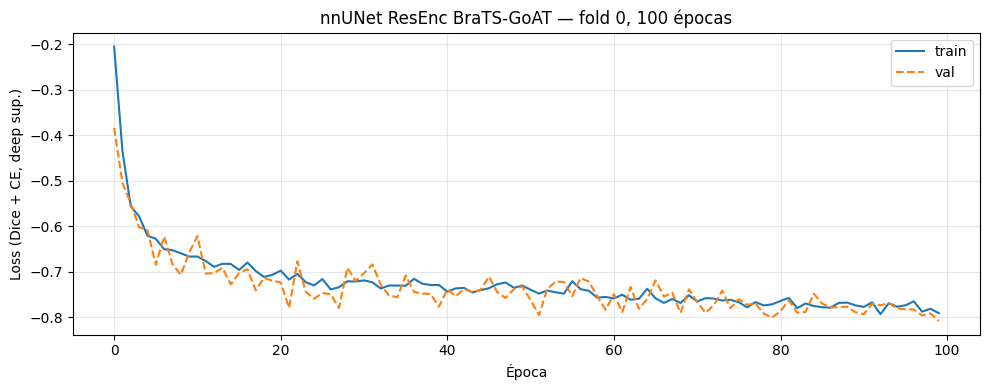

In [18]:
# Curvas de loss (treino vs validação)

%matplotlib inline
import matplotlib.pyplot as plt
plt.close('all')

trainer_dir = NNUNET_RES / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}" / f"{TRAINER}__{PLANS_NAME}__{CONFIG}" / f"fold_{FOLD}"

ckpt_path = trainer_dir / "checkpoint_final.pth"
if not ckpt_path.exists():
    ckpt_path = trainer_dir / "checkpoint_best.pth"
print("Lendo histórico de:", ckpt_path)

ckpt = torch.load(str(ckpt_path), map_location="cpu", weights_only=False)
log = ckpt.get("logging", {})
train_losses = log.get("train_losses", [])
val_losses   = log.get("val_losses",   [])
print(f"Épocas registradas: train={len(train_losses)} | val={len(val_losses)}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label="train")
ax.plot(val_losses,   label="val", ls="--")
ax.set_xlabel("Época")
ax.set_ylabel("Loss (Dice + CE, deep sup.)")
ax.set_title(f"nnUNet ResEnc BraTS-GoAT — fold {FOLD}, {len(train_losses)} épocas")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(trainer_dir / "loss_curves.png", dpi=150)
plt.show()

---
## test_GLI-MET-MEN

In [19]:
# Dice — test_GLI-MET-MEN
_SUB = "test_GLI-MET-MEN"
_ids = test_ids_by_subfolder[_SUB]

df[df["subfolder"] == _SUB][["dice_c1", "dice_c2", "dice_ET", "dice_WT", "dice_TC"]].describe()

,dice_c1,dice_c2,dice_ET,dice_WT,dice_TC
count,204.000000,204.000000,204.000000,204.000000,204.000000
mean,0.786884,0.847404,0.818396,0.912396,0.892270
std,0.270841,0.179356,0.268895,0.141637,0.186595
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.756490,0.808487,0.849780,0.912669,0.901529
50%,0.900570,0.903882,0.918909,0.950090,0.953227
75%,0.960753,0.956037,0.952566,0.974927,0.977196
max,1.000000,1.000000,1.000000,0.990710,0.990872


In [20]:
# HD95 — test_GLI-MET-MEN
df_hd95[df_hd95["subfolder"] == _SUB][["hd95_c1", "hd95_c2", "hd95_ET", "hd95_WT", "hd95_TC"]].describe()

,hd95_c1,hd95_c2,hd95_ET,hd95_WT,hd95_TC
count,196.000000,202.000000,191.000000,203.000000,200.000000
mean,4.523218,3.971642,5.140317,5.039080,6.555704
std,9.016216,7.020550,14.150613,11.615808,16.915069
min,0.000000,0.000000,0.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000,1.000000,1.000000
50%,1.414214,2.000000,1.000000,2.000000,1.414214
75%,4.387208,4.242641,2.000000,4.061553,3.000000
max,84.669947,71.888802,110.612838,110.612838,110.612838



Paciente: BraTS-GoAT-01981 | split=test/test_GLI-MET-MEN | z=95
Dice C1 (necrose/non-enh): 0.8024
Dice C2 (edema):           0.0000
Dice ET (enhancing):       0.9346
Dice WT:                   0.9216
Dice TC:                   0.9677



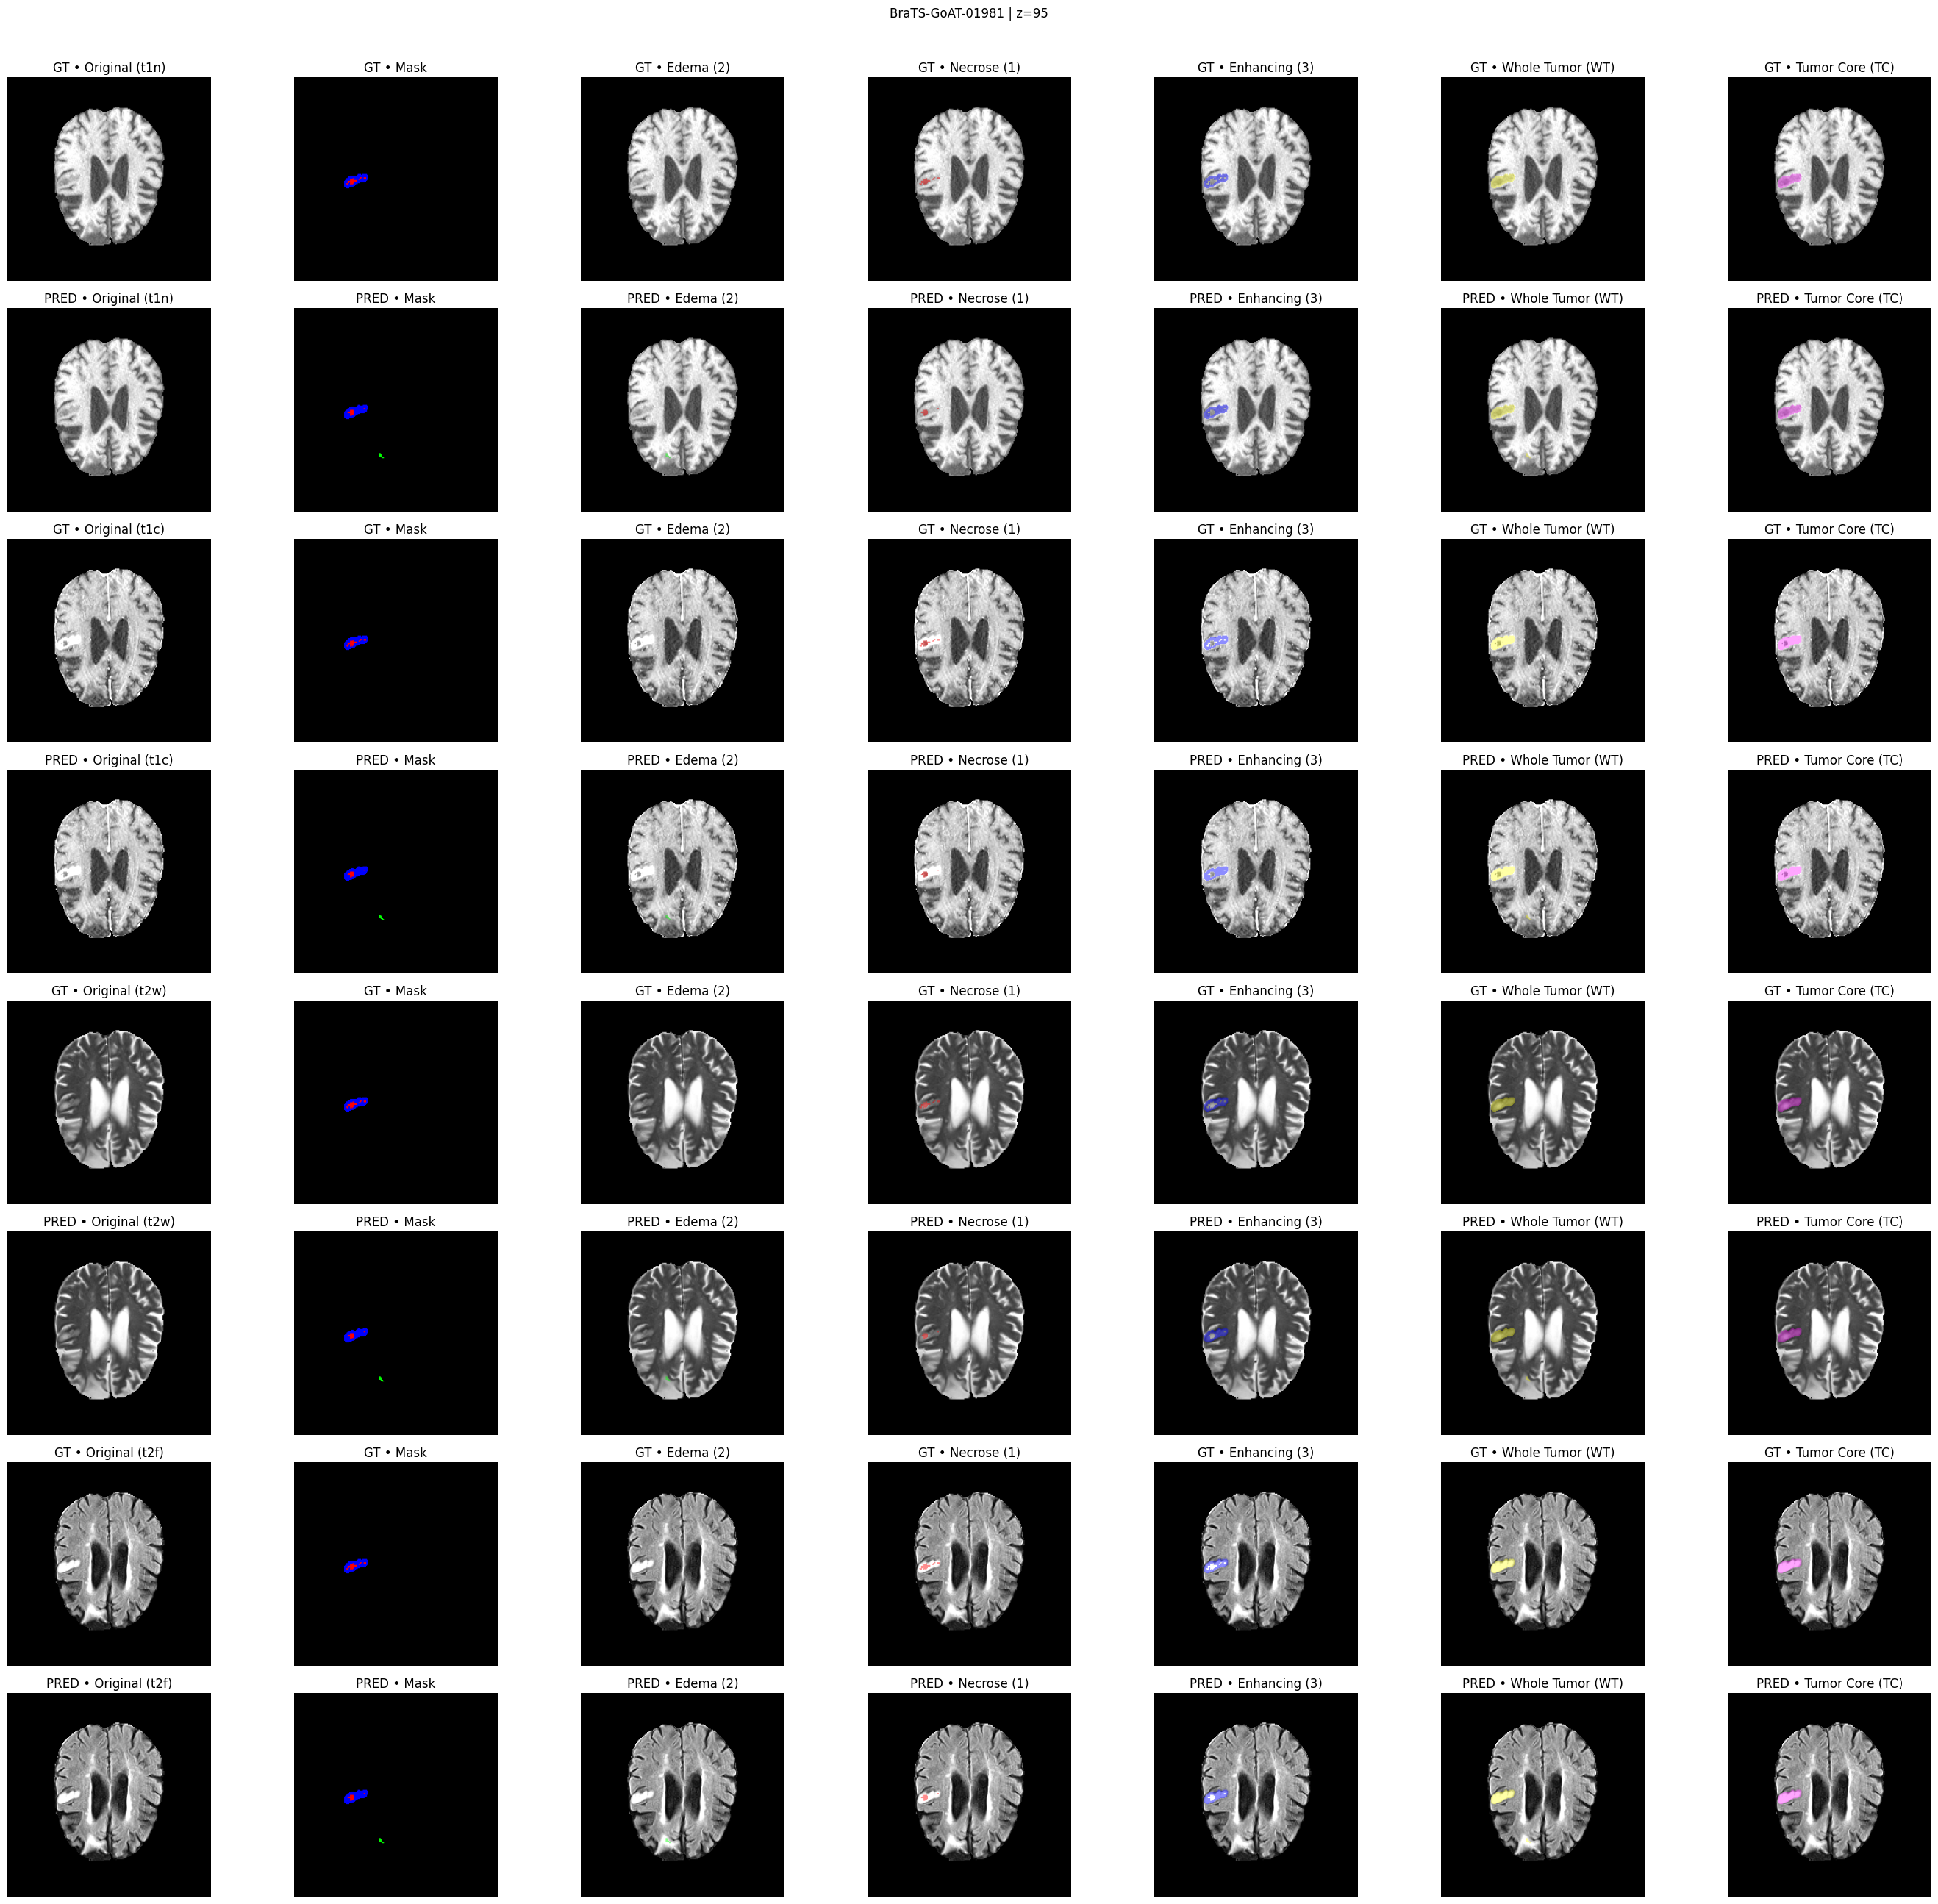

In [21]:
cid, z, dice_dict = plot_random_case_multimodal_gt_pred(_ids, split_name=f"test/{_SUB}", seed=None)

---
## test — PED

In [22]:
# Dice — PED
_SUB = "PED"
_ids = test_ids_by_subfolder[_SUB]

df[df["subfolder"] == _SUB][["dice_c1", "dice_c2", "dice_ET", "dice_WT", "dice_TC"]].describe()

,dice_c1,dice_c2,dice_ET,dice_WT,dice_TC
count,99.000000,99.000000,99.000000,99.000000,99.000000
mean,0.280505,0.140146,0.563648,0.877945,0.456605
std,0.295593,0.270608,0.365827,0.118417,0.316963
min,0.000000,0.000000,0.000000,0.125237,0.000000
25%,0.011146,0.000000,0.023692,0.857023,0.179630
50%,0.166458,0.000000,0.697358,0.909449,0.471235
75%,0.529813,0.107240,0.870655,0.937412,0.732280
max,0.896439,0.954610,1.000000,0.975326,0.973992


In [23]:
# HD95 — PED
df_hd95[df_hd95["subfolder"] == _SUB][["hd95_c1", "hd95_c2", "hd95_ET", "hd95_WT", "hd95_TC"]].describe()

,hd95_c1,hd95_c2,hd95_ET,hd95_WT,hd95_TC
count,87.000000,57.000000,87.000000,99.000000,94.000000
mean,18.566278,28.203875,9.652748,4.797566,16.974989
std,12.115847,18.529977,15.628274,4.553929,13.131560
min,2.828427,1.000000,0.000000,1.000000,1.414214
25%,10.532980,13.416408,2.000000,2.118034,7.542362
50%,15.937377,26.107469,3.162278,3.316625,14.088098
75%,24.083189,40.373258,12.474847,5.743903,22.322785
max,64.706259,81.663946,98.799270,26.153394,60.811183



Paciente: BraTS-PED-00109-000 | split=test/PED | z=36
Dice C1 (necrose/non-enh): 0.2854
Dice C2 (edema):           0.1556
Dice ET (enhancing):       0.9294
Dice WT:                   0.9336
Dice TC:                   0.5310



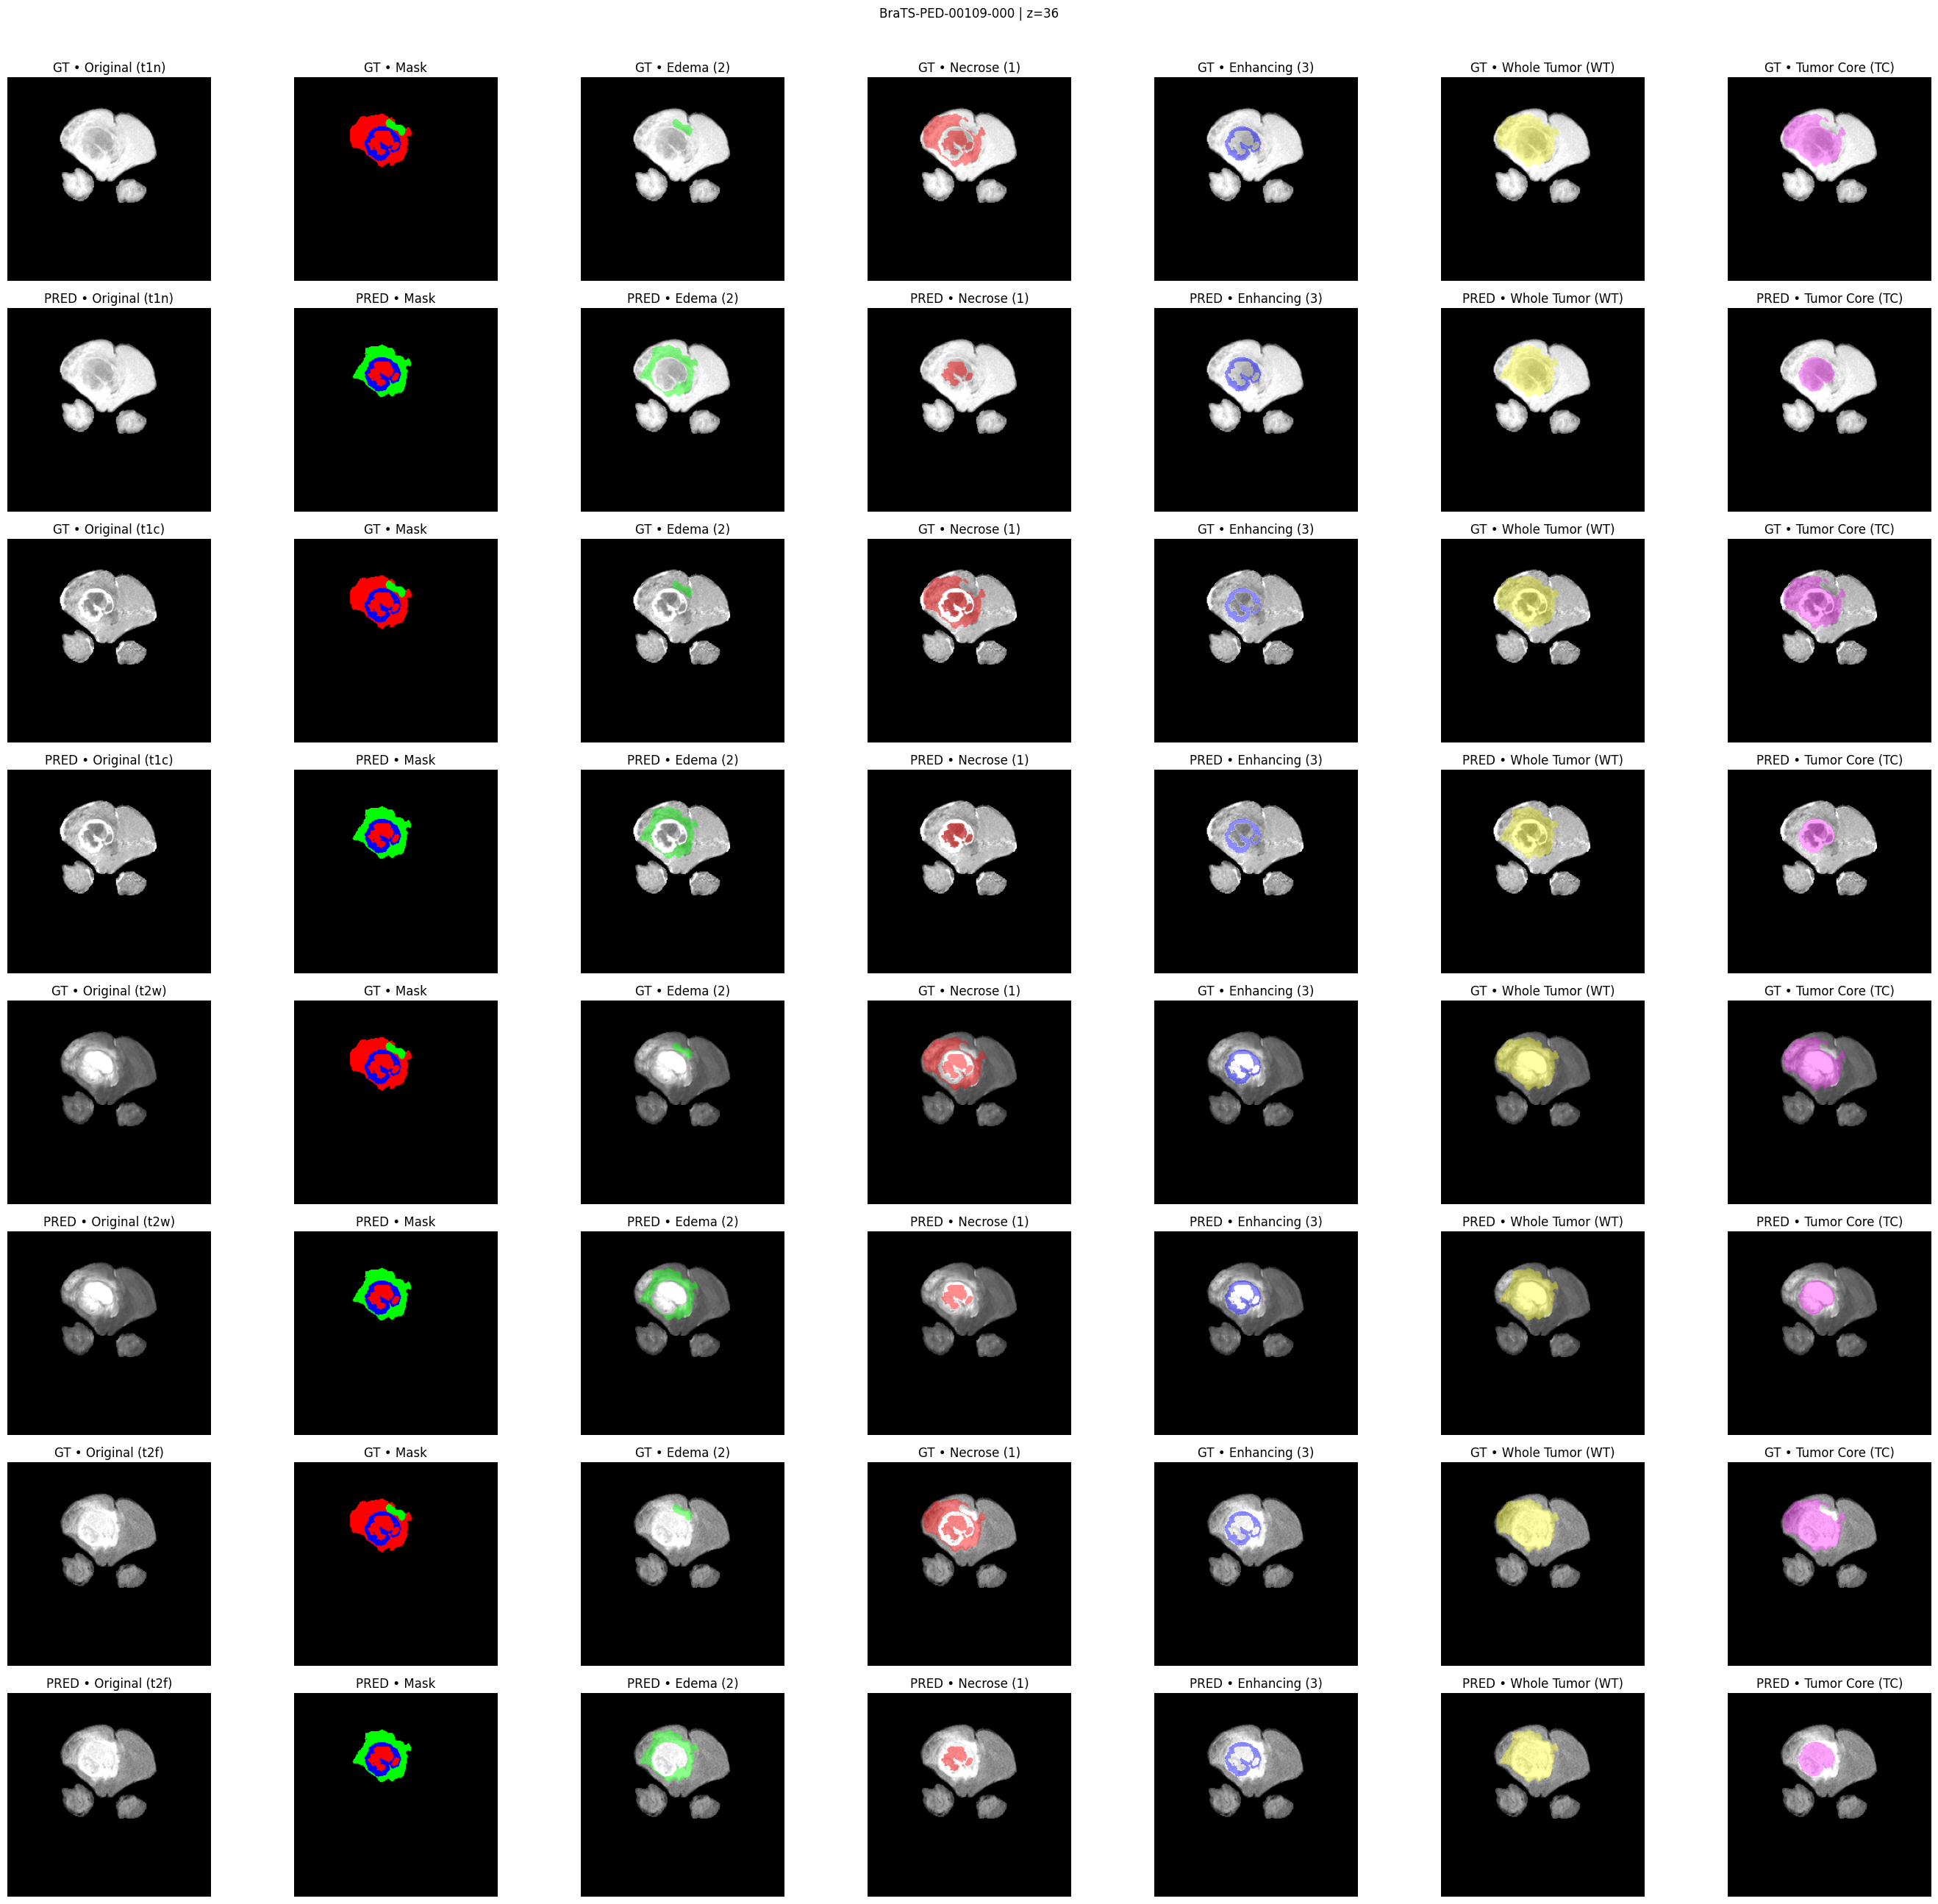

In [24]:
cid, z, dice_dict = plot_random_case_multimodal_gt_pred(_ids, split_name=f"test/{_SUB}", seed=None)

---
## test — SSA

In [25]:
# Dice — SSA
_SUB = "SSA"
_ids = test_ids_by_subfolder[_SUB]

df[df["subfolder"] == _SUB][["dice_c1", "dice_c2", "dice_ET", "dice_WT", "dice_TC"]].describe()

,dice_c1,dice_c2,dice_ET,dice_WT,dice_TC
count,146.000000,146.000000,146.000000,146.000000,146.000000
mean,0.565246,0.783158,0.776362,0.897745,0.812476
std,0.321609,0.195374,0.211101,0.108182,0.234000
min,0.000000,0.000000,0.000000,0.306095,0.000000
25%,0.338252,0.721555,0.751462,0.884624,0.811428
50%,0.686422,0.849792,0.858984,0.929874,0.903366
75%,0.840174,0.916909,0.902001,0.956492,0.936424
max,0.962633,0.969209,0.981025,0.979374,0.981394


In [26]:
# HD95 — SSA
df_hd95[df_hd95["subfolder"] == _SUB][["hd95_c1", "hd95_c2", "hd95_ET", "hd95_WT", "hd95_TC"]].describe()

,hd95_c1,hd95_c2,hd95_ET,hd95_WT,hd95_TC
count,133.000000,145.000000,144.000000,146.000000,145.000000
mean,10.007415,6.402400,6.155286,6.996030,8.494863
std,12.497562,9.084628,10.560242,10.669214,13.321624
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.000000,2.236068,2.000000,2.236068,2.236068
50%,5.744563,3.741657,2.828427,3.316625,3.162278
75%,12.041595,6.164414,5.385165,5.830952,8.062258
max,87.653054,66.280464,82.294592,67.200818,86.377080



Paciente: BraTS-SSA-00196-000 | split=test/SSA | z=58
Dice C1 (necrose/non-enh): 0.8423
Dice C2 (edema):           0.8367
Dice ET (enhancing):       0.7678
Dice WT:                   0.8513
Dice TC:                   0.7856



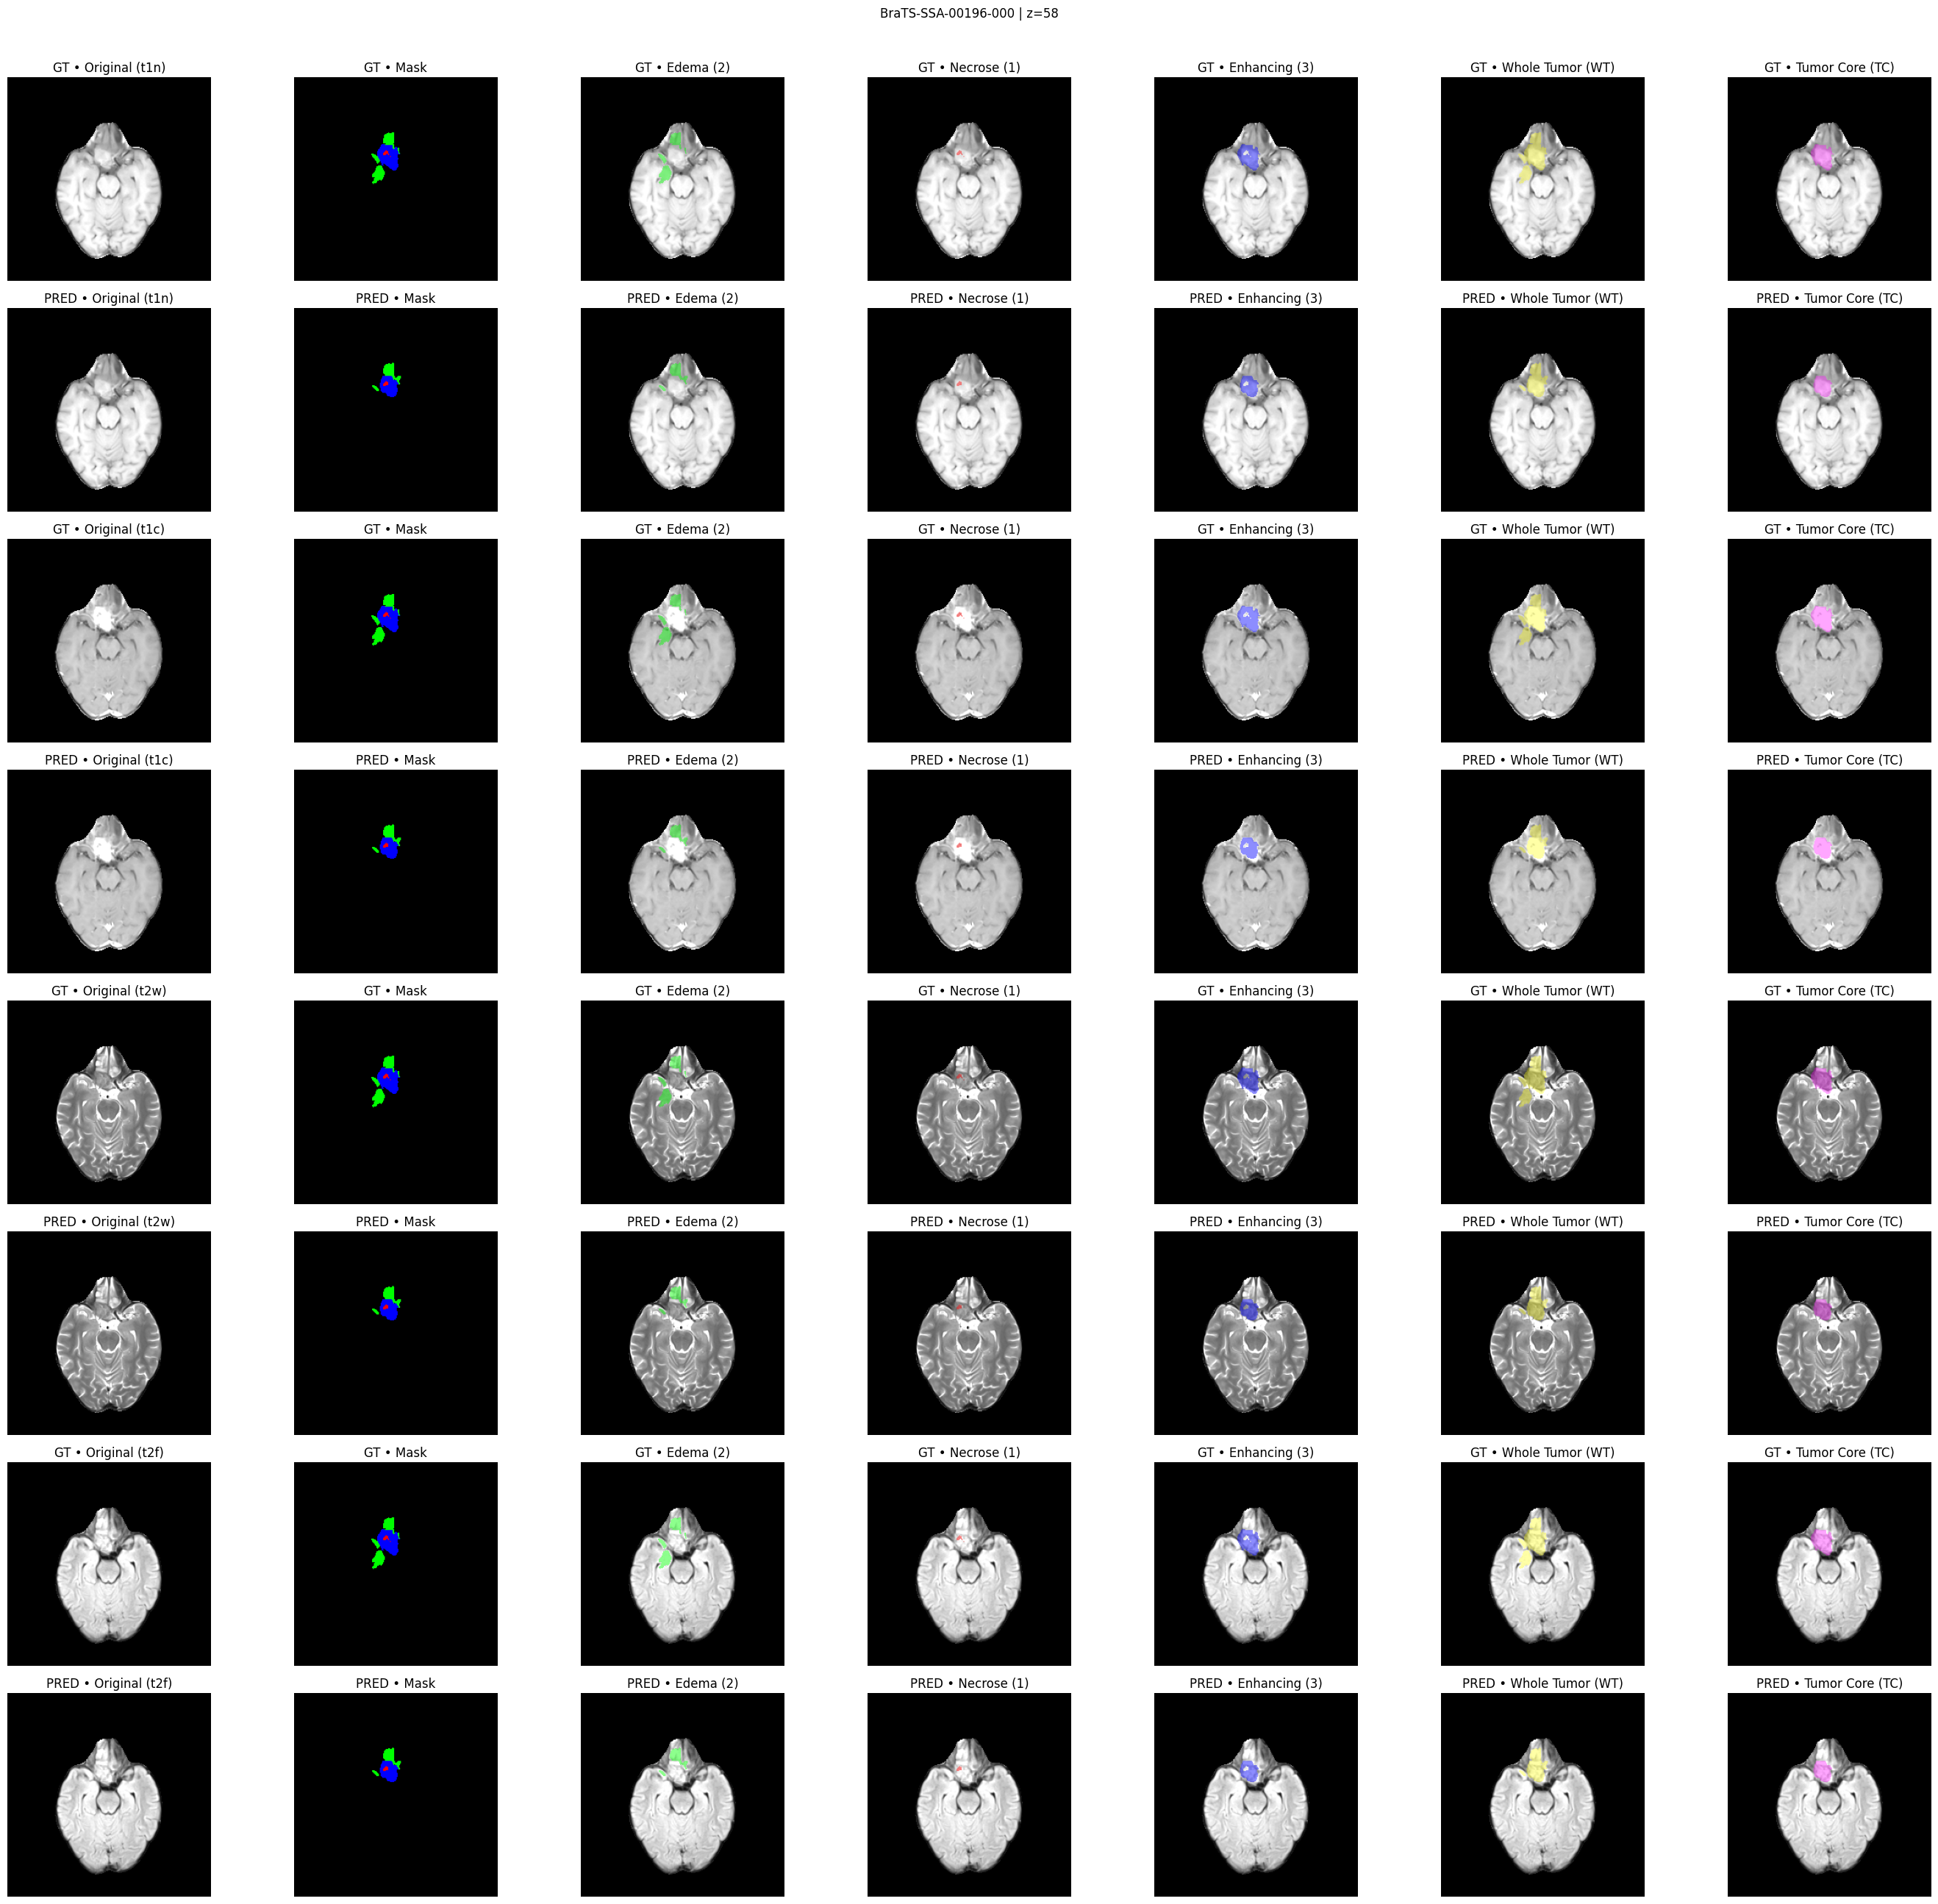

In [27]:
cid, z, dice_dict = plot_random_case_multimodal_gt_pred(_ids, split_name=f"test/{_SUB}", seed=None)